# Combine local IQ models: hg19 pcg vs txg

In [1]:
library(prego)
library(iceqream)
options(tidyverse.quiet = TRUE)
library(tidyverse)
library(purrr)
library(tgutil)
library(misha)
library(misha.ext)
library(glue)
library(here)
library(tgstat)

gsetroot(here("data/hg19"))
options(gmax.data.size = 1e+9)
source(here("code/model-utils.R"))

Loading required package: misha

here() starts at /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm



In [2]:
setwd(here())

In [3]:
here()

[1] "/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm"

In [4]:
cgd <- fread(here("output/cgd_hg19_iq_second.tsv"))
rownames(cgd) <- cgd$id
add_feats <- readr::read_rds(here("output/add_feats_hg19_iq.rds"))
add_feats <- add_feats[rownames(cgd), ]
cgd$f_tss <- cgd$tss_dist == 0

In [5]:
head(cgd)

,chrom,start,end,id,l,es_k27_max,es_k4_max,es_k27_cov,es_k4_cov,es_biv_cov,⋯,txg,l500,f_out,txg_pcg,resp10,f_ambig,tss_gene,orig_resp10,type,f_tss
,<chr>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<lgl>,<chr>,<int>,<chr>,<lgl>
5S_rRNA.2,chr1,41826605,41828380,5S_rRNA.2,1775,110.25,90.60000,0.38202247,0.0000000,0.33707865,⋯,FALSE,TRUE,FALSE,0.1035574,0.1035574,TRUE,5S_rRNA,NA,train,FALSE
5S_rRNA.3,chr1,41831862,41832691,5S_rRNA.3,829,17.00,88.75000,0.00000000,0.7619048,0.00000000,⋯,FALSE,TRUE,FALSE,0.4733907,0.4733907,TRUE,5S_rRNA,NA,train,FALSE
5S_rRNA.4,chr1,41847183,41849391,5S_rRNA.4,2208,29.45,117.05000,0.05405405,0.8018018,0.01801802,⋯,FALSE,TRUE,FALSE,0.3946410,0.3946410,TRUE,5S_rRNA,NA,train,FALSE
5S_rRNA.17,chr11,129148390,129150003,5S_rRNA.17,1613,5.95,124.00000,0.00000000,0.8048780,0.00000000,⋯,FALSE,TRUE,FALSE,0.6447502,0.6447502,FALSE,5S_rRNA,NA,train,FALSE
5S_rRNA.20,chr2,74210992,74212926,5S_rRNA.20,1934,10.00,147.95000,0.00000000,1.0000000,0.00000000,⋯,TRUE,TRUE,FALSE,0.6651161,0.6651161,FALSE,5S_rRNA,1,test,FALSE
5S_rRNA.21,chr2,74229354,74230245,5S_rRNA.21,891,5.00,98.30001,0.00000000,0.7608696,0.00000000,⋯,FALSE,TRUE,FALSE,0.6403981,0.6403981,FALSE,5S_rRNA,NA,test,FALSE


In [6]:
table(cgd$type)



 test train 
 2470 11531 

In [30]:
table(cgd$orig_resp10)



   0    1 
1698 3638 

In [27]:
dim(cgd)

[1] 14001    46

In [3]:
cgd_all = cgd_all = fread( here("output/cgd_hg19_iq.tsv"), sep = "\t", quote = FALSE)

In [4]:
set.seed(60427)
model_list <- load_models("_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg", rename = FALSE)
rename_models(model_list, "_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg")

→ Renaming full models

→ Renaming model "5"

→ Matching Sp1.2

→ Matched with "HOMER.Sp1", PSSM correlation = 0.660494457727532

→ Matching ETS

→ Matched with "HOMER.ETS", PSSM correlation = 0.765282685845344

→ Matching YY1

→ Matched with "HOMER.YY1", PSSM correlation = 0.81431641879816

→ Matching ETS1.2

→ Matched with "HOMER.ETS1", PSSM correlation = 0.87186923533612

→ Matching Egr2

→ Matched with "HOMER.Egr2", PSSM correlation = 0.742436294162996

→ Matching Klf4

→ Matched with "HOMER.Klf4", PSSM correlation = 0.813670564719117

→ Matching CRE

→ Matched with "HOMER.CRE", PSSM correlation = 0.804690579718533

→ Matching ETS1

→ Matched with "HOMER.ETS1", PSSM correlation = 0.883651252029852

→ Matching Sp1

→ Matched with "HOMER.Sp1", PSSM correlation = 0.91547374664879

→ Matching E2F1

→ Matched with "HOMER.E2F1", PSSM correlation = 0.78318579384703

Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message:
“glmnet.fit: algori

→ Matching NRF1

→ Matched with "HOMER.NRF1", PSSM correlation = 0.832351352701554

→ Matching NF1_halfsite

→ Matched with "HOMER.NF1_halfsite", PSSM correlation = 0.76640636920236

→ Matching KLF5

→ Matched with "HOMER.KLF5", PSSM correlation = 0.800590885929077

→ Matching YY1

→ Matched with "HOMER.YY1", PSSM correlation = 0.902098360145579

→ Matching Atf1

→ Matched with "HOMER.Atf1", PSSM correlation = 0.691495849534117

→ Matching Pit1

→ Matched with "HOMER.Pit1", PSSM correlation = 0.505750431221846

Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message:
“glmnet.fit: algorithm did not converge”
→ Renaming model "5_pad"

→ Matching Jun_AP1

→ Matched with "HOMER.Jun_AP1", PSSM correlation = 0.815354462760487

→ Matching KLF5

→ Matched with "HOMER.KLF5", PSSM correlation = 0.882751089828118

→ Matching JunD

→ Matched with "HOMER.JunD", PSSM correlation = 0.863181946933636

→ Matching TEAD2

→ Matched with "HOMER.TEAD2", PSSM 

$`5`
NULL

$`3`
NULL

$`5_pad`
NULL

$`3_pad`
NULL

In [3]:
#old
model_list <- load_models("_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg", rename = FALSE)
rename_models(model_list, "_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg", k27_column = "k27_l10")

→ Renaming full models

→ Renaming model "5"

→ Matching Elk4

→ Matched with "HOMER.Elk4", PSSM correlation = 0.717623902313311

→ Matching ETS1

→ Matched with "HOMER.ETS1", PSSM correlation = 0.885306330928511

→ Matching Atf7

→ Matched with "HOMER.Atf7", PSSM correlation = 0.618162092565979

→ Matching YY1

→ Matched with "HOMER.YY1", PSSM correlation = 0.80340613013752

→ Matching KLF5

→ Matched with "HOMER.KLF5", PSSM correlation = 0.800044715138123

→ Matching ETS

→ Matched with "HOMER.ETS", PSSM correlation = 0.617312971896137

→ Matching NRF1

→ Matched with "HOMER.NRF1", PSSM correlation = 0.883282215680623

→ Matching Elk1

→ Matched with "HOMER.Elk1", PSSM correlation = 0.639395788103266

→ Matching Egr1

→ Matched with "HOMER.Egr1", PSSM correlation = 0.509873260447389

→ Matching GATA3_1

→ Matched with "HOMER.GATA3_1", PSSM correlation = 0.582468988030693

→ Renaming model "3"

→ Matching Unknown3_1

→ Matched with "HOMER.Unknown3_1", PSSM correlation = 0.652419209224

$`5`
NULL

$`3`
NULL

$`5_pad`
NULL

$`3_pad`
NULL

In [61]:
cgd$response = cgd$orig_resp10

In [63]:
table(cgd$orig_resp10)


   0    1 
1698 3638 

In [69]:
cgd$f_train = cgd$type == "train"
cgd$f_test = cgd$type == "test"

In [70]:
model_list <- load_models("_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg", rename = TRUE)
models_auc <- calc_all_auc(model_list, cgd)

Warning message in roc.default(obs[cgd$f_test & cgd$f_tss], traj_model@predicted_diff_score[cgd$f_test & :
“'response' has more than two levels. Consider setting 'levels' explicitly or using 'multiclass.roc' instead”
Warning message in roc.default(obs[!cgd$f_test & cgd$f_tss], traj_model@predicted_diff_score[!cgd$f_test & :
“'response' has more than two levels. Consider setting 'levels' explicitly or using 'multiclass.roc' instead”
Warning message in roc.default(obs[cgd$f_test], traj_model@predicted_diff_score[cgd$f_test]):
“'response' has more than two levels. Consider setting 'levels' explicitly or using 'multiclass.roc' instead”
Warning message in roc.default(obs[!cgd$f_test], traj_model@predicted_diff_score[!cgd$f_test]):
“'response' has more than two levels. Consider setting 'levels' explicitly or using 'multiclass.roc' instead”
Warning message in roc.default(obs[cgd$f_test & !cgd$f_tss], traj_model@predicted_diff_score[cgd$f_test & :
“'response' has more than two levels. Consider

Warning message in roc.default(obs[!cgd$f_test], traj_model@predicted_diff_score[!cgd$f_test]):
“'response' has more than two levels. Consider setting 'levels' explicitly or using 'multiclass.roc' instead”
Warning message in roc.default(obs[cgd$f_test & !cgd$f_tss], traj_model@predicted_diff_score[cgd$f_test & :
“'response' has more than two levels. Consider setting 'levels' explicitly or using 'multiclass.roc' instead”
Warning message in roc.default(obs[!cgd$f_test & !cgd$f_tss], traj_model@predicted_diff_score[!cgd$f_test & :
“'response' has more than two levels. Consider setting 'levels' explicitly or using 'multiclass.roc' instead”
Warning message in roc.default(obs[cgd$f_test & cgd$f_tss], traj_model@predicted_diff_score[cgd$f_test & :
“'response' has more than two levels. Consider setting 'levels' explicitly or using 'multiclass.roc' instead”
Warning message in roc.default(obs[!cgd$f_test & cgd$f_tss], traj_model@predicted_diff_score[!cgd$f_test & :
“'response' has more than two 

## Combined model

In [5]:
##new
source(here::here("code/model-utils.R"))
binary_resp <- cgd %>% select(id, orig_resp10) %>% deframe()
binary_resp <- binary_resp[model_list$full[[1]]@peak_intervals$id]
y <- cgd %>% select(id, l10_h1_k27_sum) %>% deframe()
y <- y[model_list$full[[1]]@peak_intervals$id]
set.seed(60427)
cli::cli_h1("Full model")
traj_model_comb <- combine_models.cv(model_list$full, family = "gaussian", eval_y = binary_resp, y = y) %fcache_rds% here("output/traj_model_comb_delta_hg19.rds")
cli::cli_h1("Filtered model")
traj_model_comb_f <- combine_models.cv(model_list$filtered, family = "gaussian", eval_y = binary_resp, y = y) %fcache_rds% here("output/traj_model_comb_f_delta_hg19.rds")
cli::cli_h1("Filtered model with interactions")
traj_model_comb_f_inter <- combine_models.cv(model_list$filtered, add_interactions = T, add_feats = add_feats, family = "gaussian", inter_thresh = 0.001, eval_y = binary_resp, y = y) %fcache_rds%here("output/traj_model_comb_f_inter_delta_hg19.rds")



── Full model ──────────────────────────────────────────────────────────────────

ℹ eval_y has 8665 NA values, 1698 0s and 3638 1s

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8

→ rsq train: 0.387416981323282, rsq test: 0.425300412441291. Number of motifs: 40

→ AUC on eval_y train: 0.944801947921682, AUC on eval_y test: 0.9446361963915



── Filtered model ──────────────────────────────────────────────────────────────

ℹ eval_y has 8665 NA values, 1698 0s and 3638 1s

→ rsq train: 0.379746794710152, rsq test: 0.425310321574602. Number of motifs: 29

→ AUC on eval_y train: 0.940500872652865, AUC on eval_y test: 0.944205809380749



── Filtered model with interactions ────────────────────────────────────────────

ℹ eval_y has 8665 NA values, 1698 0s and 3638 1s

ℹ Adding interactions with threshold 0.001. Number of variables eligible for interactions: 28 out of 29

In [ ]:
###doesn't work for traj_model_comb_f_inter!!!

In [12]:
###doesn't work for traj_model_comb_f_inter!!!
source(here::here("code/model-utils.R"))
p <- combine_models.cv.predict(traj_model_comb_f_inter, model_list$filtered, cgd_all)
cgd_all <- cgd_all%>%
    mutate(pred = p)
motif_db <- purrr::imap_dfr(traj_model_comb_f@motif_models, ~ .x$pssm %>% dplyr::mutate(motif = .y))
fwrite(motif_db, here("output/iq-hg19-model_motif_db-diff-preds.tsv"), sep = "\t")


→ Calculating energies

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 14001 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 14001 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 34153 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 14001 normalization intervals

→ Creating sequence features



ERROR: Error in X[, colnames(comb_model@model_features)]: subscript out of bounds


In [13]:
source(here::here("code/model-utils.R"))
p <- combine_models.cv.predict(traj_model_comb_f, model_list$filtered, cgd_all)
cgd_all <- cgd_all%>%
    mutate(pred = p)
motif_db <- purrr::imap_dfr(traj_model_comb_f@motif_models, ~ .x$pssm %>% dplyr::mutate(motif = .y))
fwrite(motif_db, here("output/iq-hg19-model_motif_db-diff-preds.tsv"), sep = "\t")

→ Calculating energies

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 14001 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 14001 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 34153 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 14001 normalization intervals

→ Creating sequence features



In [ ]:
##add 5mc predictions

In [14]:
head(cgd_all)

,chrom,start,end,id,l,es_k27_max,es_k4_max,es_k27_cov,es_k4_cov,es_biv_cov,⋯,l10_h1_k27_sum,pcg,txg,l500,f_out,txg_pcg,resp10,f_ambig,tss_gene,pred
,<chr>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<int>,<lgl>,<chr>,<dbl>
1,chr1,9488701,9489371,5S_rRNA.1,670,5.00,25.60,0.00000000,0.0000000,0.00000000,⋯,3.665230,FALSE,FALSE,TRUE,TRUE,NA,NA,FALSE,5S_rRNA,3.058820
2,chr1,41826605,41828380,5S_rRNA.2,1775,110.25,90.60,0.38202247,0.0000000,0.33707865,⋯,6.101676,FALSE,FALSE,TRUE,FALSE,0.1035574,NA,TRUE,5S_rRNA,4.156450
3,chr1,41831862,41832691,5S_rRNA.3,829,17.00,88.75,0.00000000,0.7619048,0.00000000,⋯,4.651147,FALSE,FALSE,TRUE,FALSE,0.4733907,NA,TRUE,5S_rRNA,3.955958
4,chr1,41847183,41849391,5S_rRNA.4,2208,29.45,117.05,0.05405405,0.8018018,0.01801802,⋯,4.947160,FALSE,FALSE,TRUE,FALSE,0.3946410,NA,TRUE,5S_rRNA,4.382694
5,chr1,41889237,41889828,5S_rRNA.5,591,0.00,2.00,0.00000000,0.0000000,0.00000000,⋯,3.321928,FALSE,FALSE,TRUE,TRUE,NA,NA,FALSE,5S_rRNA,5.167814
6,chr1,117487141,117487793,5S_rRNA.6,652,2.00,0.00,0.00000000,0.0000000,0.00000000,⋯,3.508475,FALSE,FALSE,TRUE,TRUE,NA,NA,FALSE,5S_rRNA,4.462661


In [15]:
cgd_5mc <- fread(here("output/iq-hg19-5mc-vs-nothing-model_preds.tsv")) 

In [16]:
head(cgd_5mc)

,chrom,start,end,id,l,es_k27_max,es_k4_max,es_k27_cov,es_k4_cov,es_biv_cov,⋯,blacklist,low_complex,tot_rpt,k27_k4_l10,k27_l10,k4_10,resp5mc,resp_pcg_vs_txg,tss_gene,pred
,<chr>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<dbl>
1,chr1,9488701,9489371,5S_rRNA.1,670,5.00,25.60,0.00000000,0.0000000,0.00000000,⋯,0,0.00000000,0.00000000,5.343408,3.906891,5.153805,NA,NA,5S_rRNA,0.80706759
2,chr1,41826605,41828380,5S_rRNA.2,1775,110.25,90.60,0.38202247,0.0000000,0.33707865,⋯,0,0.02247191,0.02247191,7.720073,6.909893,6.652486,1,0,5S_rRNA,0.99422900
3,chr1,41831862,41832691,5S_rRNA.3,829,17.00,88.75,0.00000000,0.7619048,0.00000000,⋯,0,0.00000000,0.00000000,6.854868,4.754887,6.625709,NA,NA,5S_rRNA,0.97990917
4,chr1,41847183,41849391,5S_rRNA.4,2208,29.45,117.05,0.05405405,0.8018018,0.01801802,⋯,0,0.10810811,0.10810811,7.290019,5.301953,6.989253,1,NA,5S_rRNA,0.98709468
5,chr1,41889237,41889828,5S_rRNA.5,591,0.00,2.00,0.00000000,0.0000000,0.00000000,⋯,0,0.00000000,0.00000000,3.584963,3.321928,3.584963,0,NA,5S_rRNA,0.02601771
6,chr1,117487141,117487793,5S_rRNA.6,652,2.00,0.00,0.00000000,0.0000000,0.00000000,⋯,0,0.00000000,0.00000000,3.584963,3.584963,3.321928,0,NA,5S_rRNA,0.58084240


In [17]:
cgd_all$pred_5mc = cgd_5mc$pred

In [18]:
fwrite(cgd_all, here("output/iq-hg19-model_preds-diff-preds.tsv"), sep = "\t")

In [ ]:
cgd_all %>% 
    ggplot(aes(x=l10_h1_k27_sum, y=pred)) +
    geom_dense_scatter() + 
    theme_bw()

In [5]:
traj_model_comb <- combine_models.cv(model_list$full)
traj_model_comb_f <- combine_models.cv(model_list$filtered) %cache_rds% here("output/traj_model_comb_f_hg19_iq_k4_vs_k27.rds")
traj_model_comb_f_inter <- combine_models.cv(model_list$filtered, add_interactions = T, add_feats = add_feats) %cache_rds% here("output/traj_model_comb_f_inter_hg19_iq_k4_vs_k27.rds")

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10

→ AUC train: 0.946055358385916, AUC test: 0.931389990311103. Number of motifs: 40

→ AUC train: 0.941834949864717, AUC test: 0.928764217845482. Number of motifs: 27

ℹ Adding interactions with threshold 0.01. Number of variables eligible for interactions: 15 out of 27

→ Number of interactions: 7

→ AUC train: 0.942166173263735, AUC test: 0.92843243419285. Number of motifs: 27



Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9154

$train_tss_auc
Area under the curve: 0.9337

$test_all_auc
Area under the curve: 0.9314

$train_all_auc
Area under the curve: 0.9461

$test_no_tss_auc
Area under the curve: 0.8284

$train_no_tss_auc
Area under the curve: 0.8855

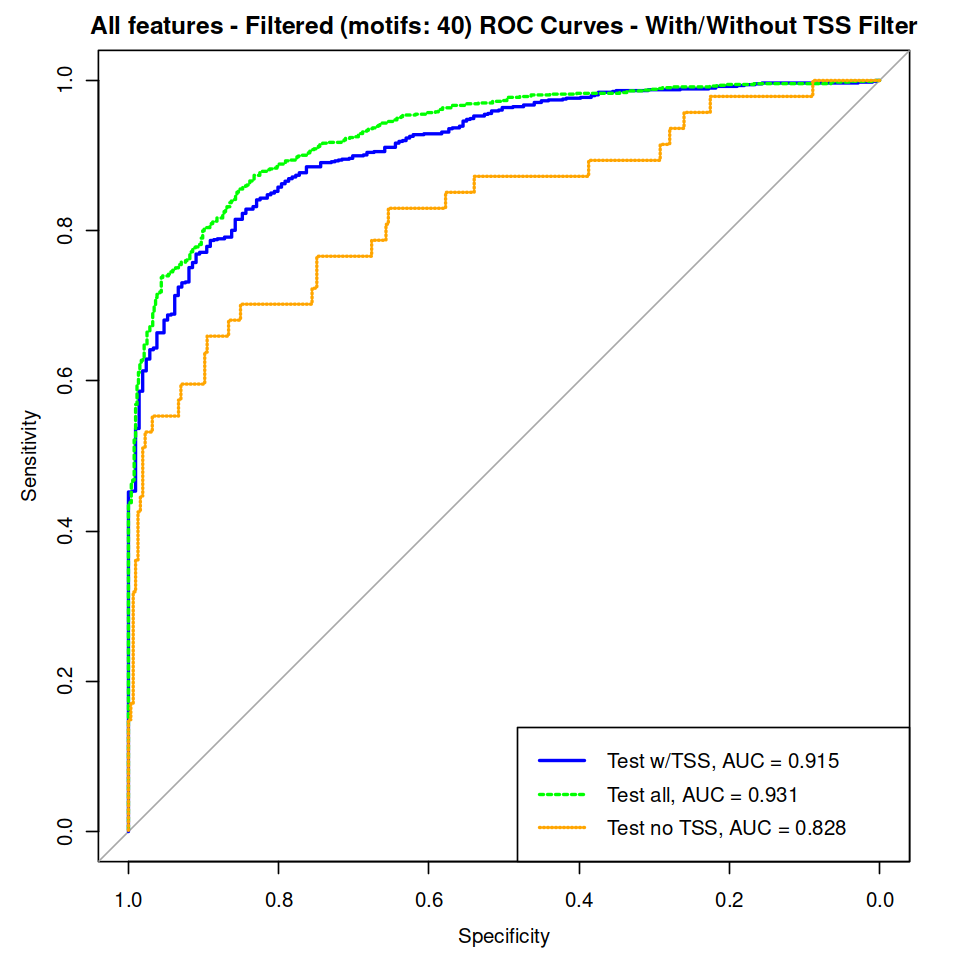

In [6]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb@motif_models)})"), plot_test_only = TRUE)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9104

$train_tss_auc
Area under the curve: 0.9271

$test_all_auc
Area under the curve: 0.9288

$train_all_auc
Area under the curve: 0.9418

$test_no_tss_auc
Area under the curve: 0.8224

$train_no_tss_auc
Area under the curve: 0.8809

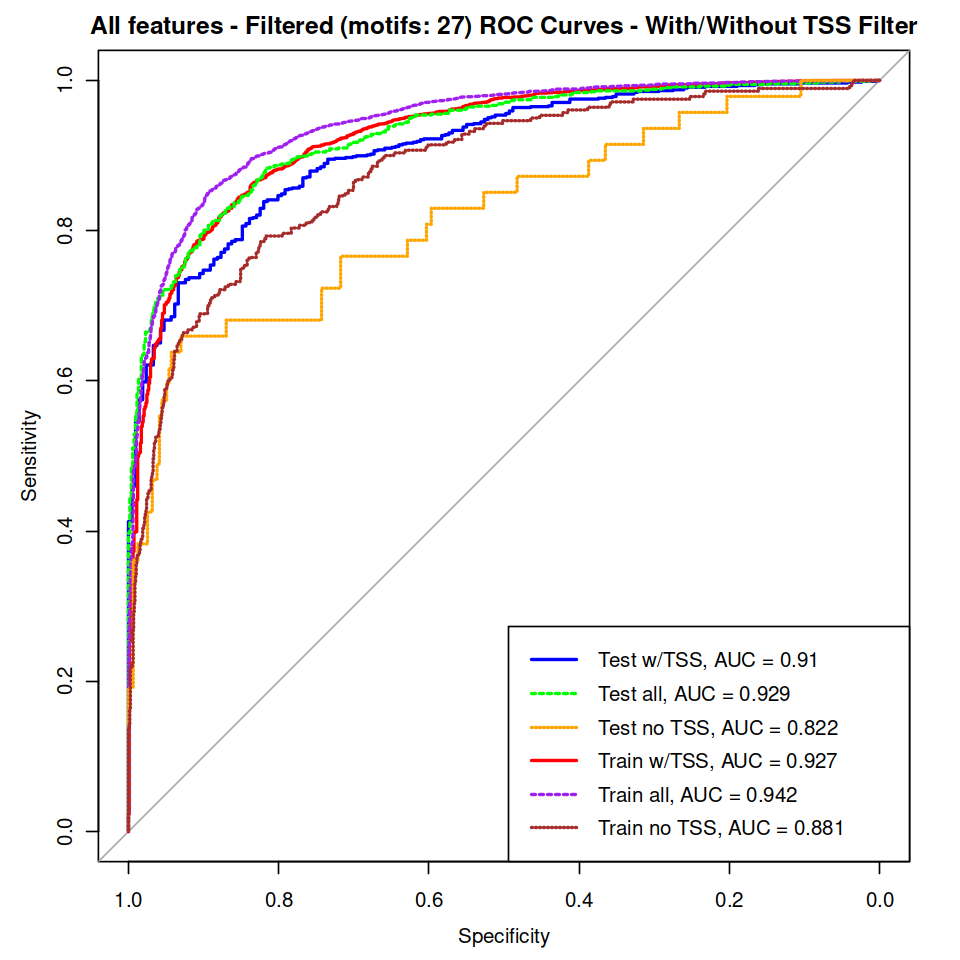

In [7]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb_f, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb_f@motif_models)})"), plot_test_only = FALSE)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9104

$train_tss_auc
Area under the curve: 0.9271

$test_all_auc
Area under the curve: 0.9288

$train_all_auc
Area under the curve: 0.9418

$test_no_tss_auc
Area under the curve: 0.8224

$train_no_tss_auc
Area under the curve: 0.8809

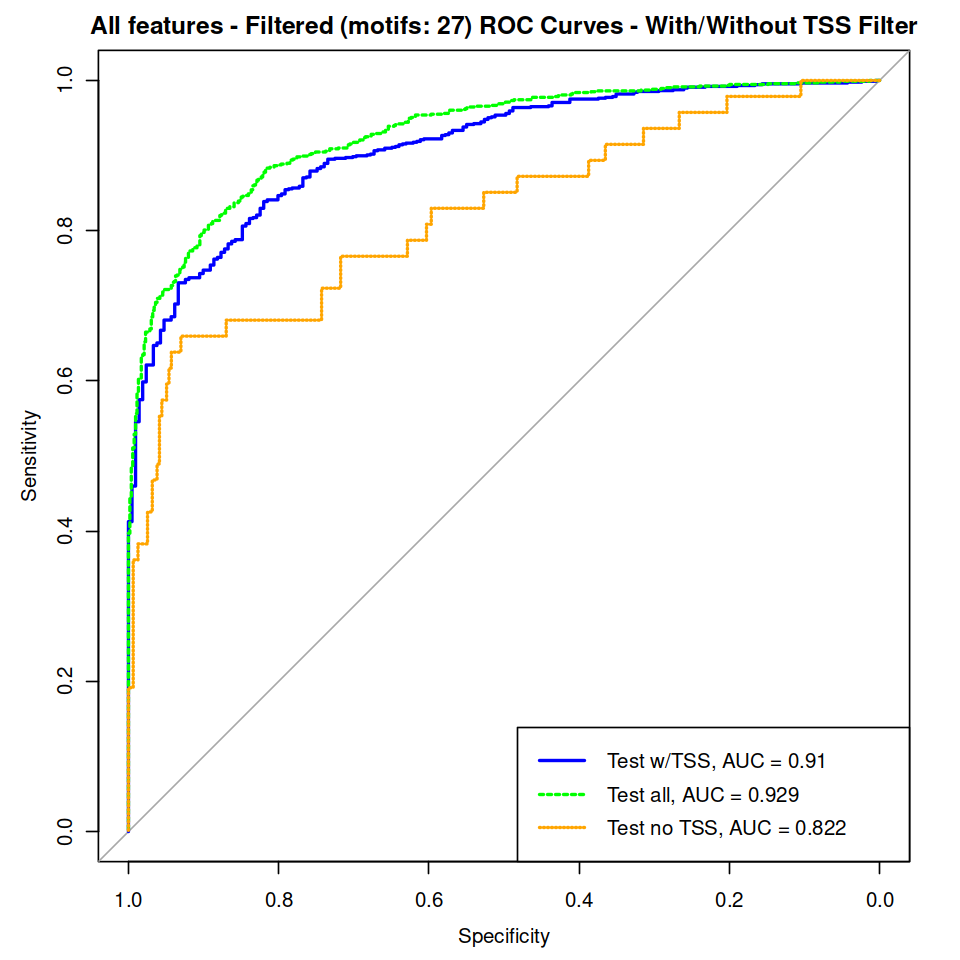

In [8]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb_f, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb_f@motif_models)})"), plot_test_only = TRUE)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9095

$train_tss_auc
Area under the curve: 0.9274

$test_all_auc
Area under the curve: 0.9284

$train_all_auc
Area under the curve: 0.9422

$test_no_tss_auc
Area under the curve: 0.8258

$train_no_tss_auc
Area under the curve: 0.8817

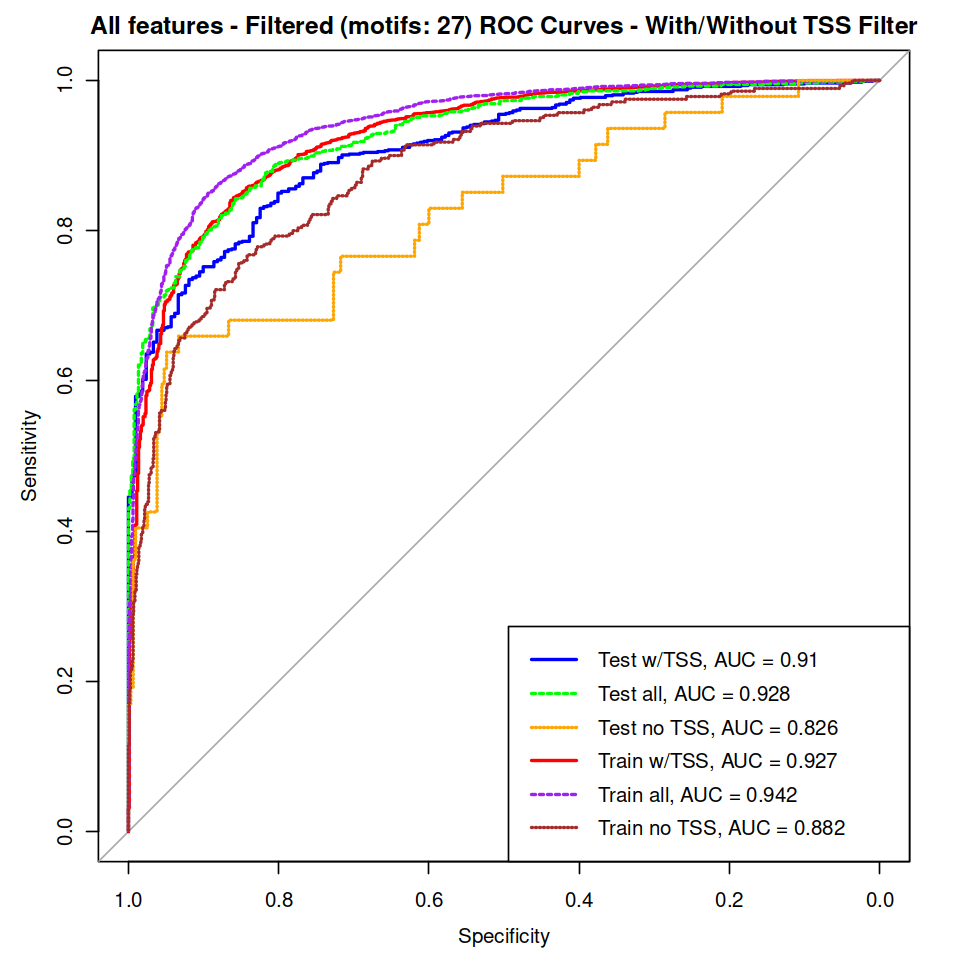

In [9]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb_f_inter, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb_f_inter@motif_models)})"), plot_test_only = FALSE)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9095

$train_tss_auc
Area under the curve: 0.9274

$test_all_auc
Area under the curve: 0.9284

$train_all_auc
Area under the curve: 0.9422

$test_no_tss_auc
Area under the curve: 0.8258

$train_no_tss_auc
Area under the curve: 0.8817

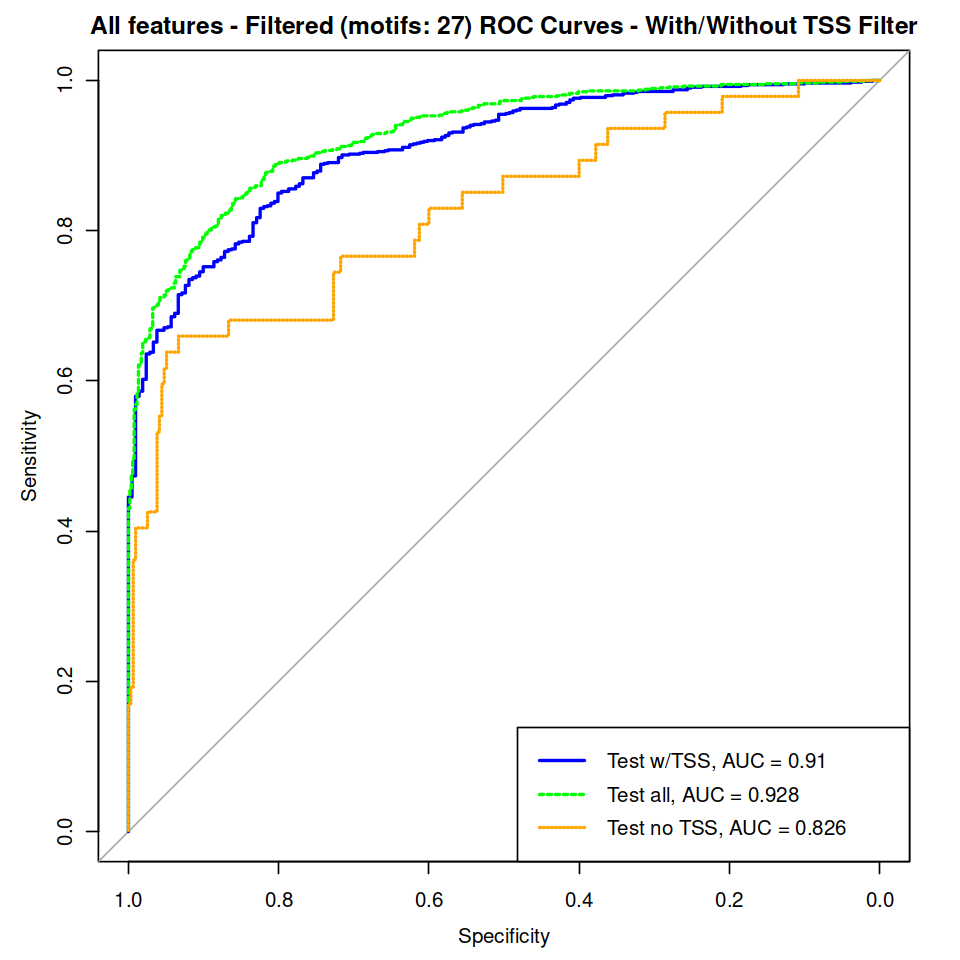

In [10]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb_f_inter, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb_f_inter@motif_models)})"), plot_test_only = TRUE)

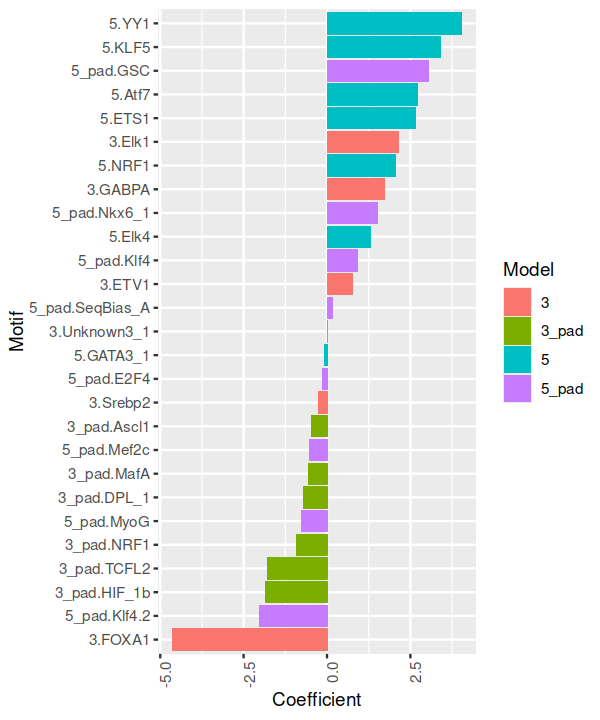

In [11]:
dinucs <- c("AA", "AC", "AG", "AT", "CA", "CC", "CG", "CT", "GA", "GC", "GG", "GT", "TA", "TC", "TG", "TT", "gc_content")
coefs <- traj_model_comb_f@coefs %>%
    filter(!gsub("^.+\\.", "", variable) %in% dinucs) %>%
    column_to_rownames("variable") %>%
    rowSums() %>%
    enframe("variable", "coef") %>%
    arrange(abs(coef)) %>%
    separate(variable, sep = "\\.", into = c("model", "motif"), extra = "merge", remove = FALSE)
set_plot_size(5, 6)
coefs %>%
    ggplot(aes(reorder(variable, coef), y = coef, fill = model)) +
    geom_col() +
    coord_flip() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Motif", y = "Coefficient", fill = "Model")

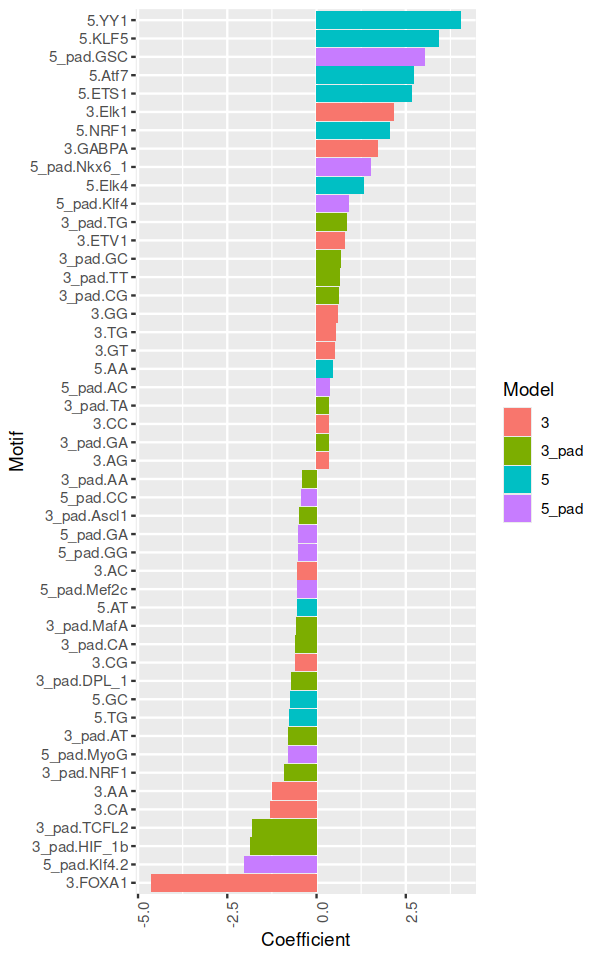

In [12]:
coefs <- traj_model_comb_f@coefs %>%
    column_to_rownames("variable") %>%
    rowSums() %>%
    enframe("variable", "coef") %>%
    arrange(abs(coef)) %>%
    separate(variable, sep = "\\.", into = c("model", "motif"), extra = "merge", remove = FALSE)
set_plot_size(5, 8)
coefs %>%
    filter(abs(coef) >= 0.3) %>%
    ggplot(aes(reorder(variable, coef), y = coef, fill = model)) +
    geom_col() +
    coord_flip() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Motif", y = "Coefficient", fill = "Model")


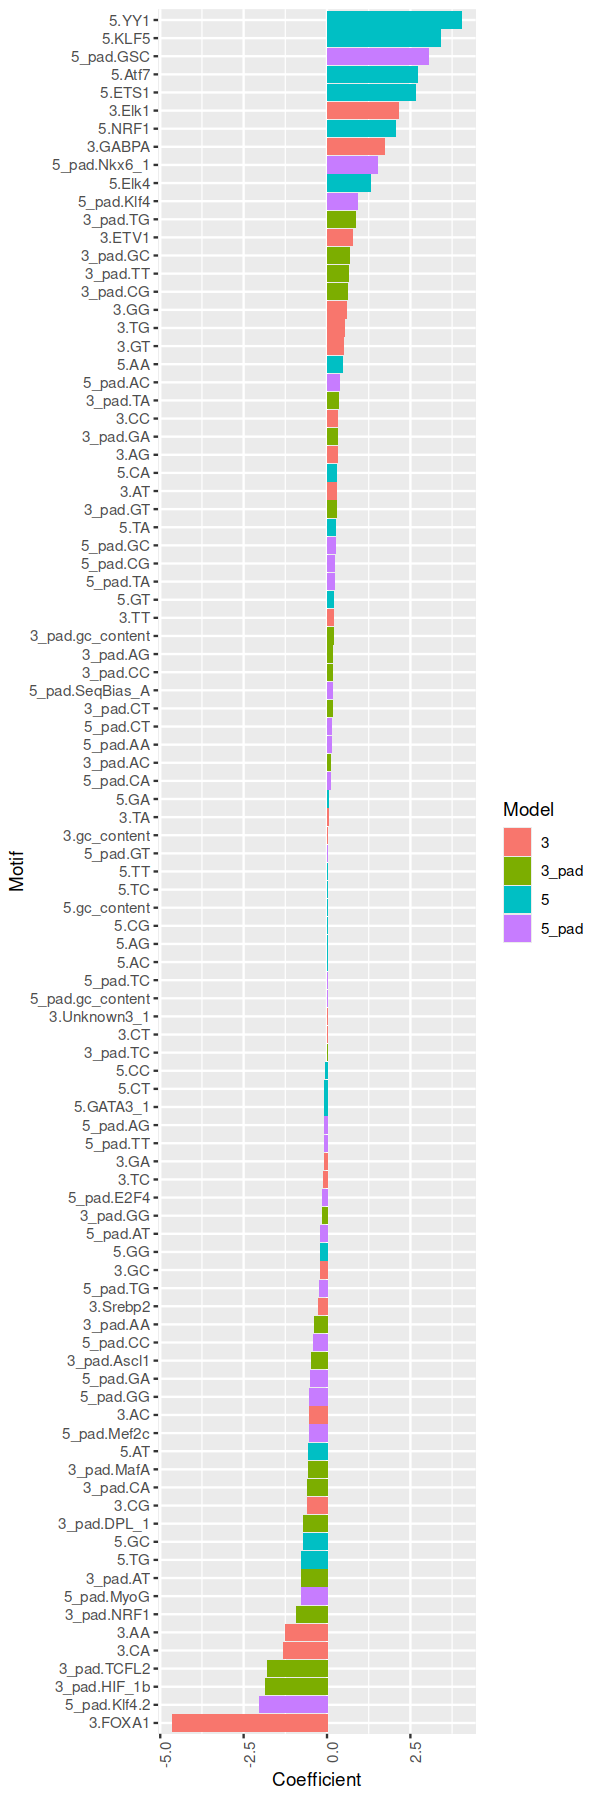

In [13]:
coefs <- traj_model_comb_f@coefs %>%
    column_to_rownames("variable") %>%
    rowSums() %>%
    enframe("variable", "coef") %>%
    arrange(abs(coef)) %>%
    separate(variable, sep = "\\.", into = c("model", "motif"), extra = "merge", remove = FALSE)
set_plot_size(5, 15)
coefs %>%
    ggplot(aes(reorder(variable, coef), y = coef, fill = model)) +
    geom_col() +
    coord_flip() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Motif", y = "Coefficient", fill = "Model")


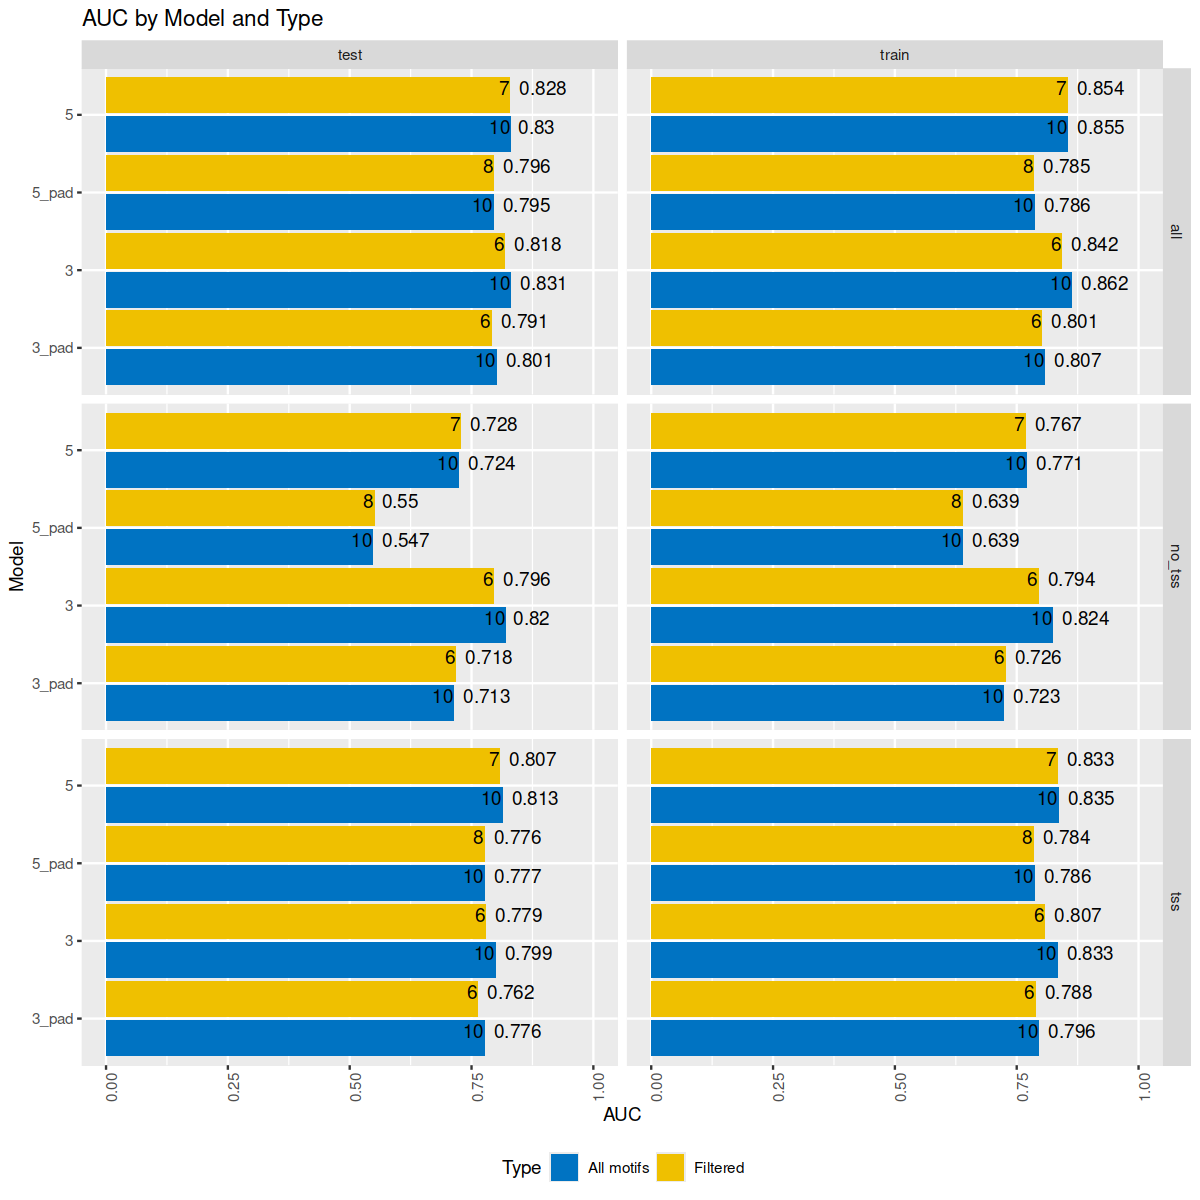

In [14]:
models_auc <- calc_all_auc(model_list, cgd)
plot_auc_by_type(models_auc)

In [21]:
dir.create(here("output/hg19-pcg-vs-txg-report"))
file.copy(here("output/iq_5_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg/iq_regression_filtered_model.pdf"), here("output/hg19-pcg-vs-txg-report/5in_oriented.pdf"), overwrite = TRUE)
file.copy(here("output/iq_5_pad_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg/iq_regression_filtered_model.pdf"), here("output/hg19-pcg-vs-txg-report/5pad_oriented.pdf"), overwrite = TRUE)
file.copy(here("output/iq_3_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg/iq_regression_filtered_model.pdf"), here("output/hg19-pcg-vs-txg-report/3in_oriented.pdf"), overwrite = TRUE)
file.copy(here("output/iq_3_pad_prego_10_motifs_no_add_oriented_hg19_pcg_vs_txg/iq_regression_filtered_model.pdf"), here("output/hg19-pcg-vs-txg-report/3pad_oriented.pdf"), overwrite = TRUE)

Warning message in dir.create(here("output/hg19-pcg-vs-txg-report")):
“'/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper/output/hg19-pcg-vs-txg-report' already exists”


[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

## Predictions

In [27]:
# cgd_all <- fread(here("output/cgd_hg19_iq.tsv"))
cgd_all <- fread(here("output/iq-hg19-5mc-vs-nothing-model_preds.tsv")) %>% mutate(pred_5mc = pred)
rownames(cgd_all) <- cgd_all$id

In [28]:
p <- combine_models.cv.predict(traj_model_comb_f, model_list$filtered, cgd)
p_all <- combine_models.cv.predict(traj_model_comb_f, model_list$filtered, cgd_all)
cgd <- cgd %>%
    mutate(pred = p[id])
cgd_all <- cgd_all %>%
    mutate(pred = p_all[id])
motif_db <- purrr::imap_dfr(traj_model_comb_f@motif_models, ~ .x$pssm %>% dplyr::mutate(motif = .y))
fwrite(motif_db, here("output/iq-hg19-pcg-vs-txg-motif_db.tsv"), sep = "\t")
fwrite(cgd_all, here("output/iq-hg19-pcg-vs-txg-model_preds.tsv"), sep = "\t")

→ Calculating energies

ℹ Extracting sequences...

ℹ Computing motif energies for 7814 intervals and 7814 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 7814 intervals and 7814 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 7814 intervals and 7814 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 7814 intervals and 7814 normalization intervals

→ Creating sequence features

→ Calculating energies

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 7814 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 7814 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 34153 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 7814 normalization intervals

→ Creating sequence features



In [29]:
cgd_all <- cgd_all %>%
    mutate(comb_pred = ifelse(pred_5mc < 0.25, 0, pred)) 
pROC::roc(cgd_all$resp_pcg_vs_txg, cgd_all$comb_pred)$auc
pROC::roc(cgd_all$resp_pcg_vs_txg, cgd_all$pred_5mc)$auc
pROC::roc(cgd_all$resp_pcg_vs_txg, cgd_all$pred)$auc


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.9342

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.6739

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.9386